# SpaceX project

In this project we want to predict if SpaceX will reuse the first stage of the rocket, if so, we will try to predict the price of the next launch.

In [289]:
import requests
import pandas as pd
import numpy as np
import datetime 
from bs4 import BeautifulSoup
import re
import sqlite3
import prettytable
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, MousePosition
from folium.features import DivIcon
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Setting this option will print all collumns of a dataframe
pd.set_option('display.max_columns', None)
# Setting this option will print all of the data in a feature
pd.set_option('display.max_colwidth', None)

pd.set_option('display.max_rows', 10)

pd.set_option('future.no_silent_downcasting', True)

prettytable.DEFAULT = 'DEFAULT'

## Get data from API

Space REST API base: https://api.spacexdata.com/v4/


In [11]:
URL_rockets = 'https://api.spacexdata.com/v4/launches/past'
data = pd.json_normalize(requests.get(URL_rockets).json())
data.head() 


,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,crew,ships,capsules,payloads,launchpad,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,auto_update,tbd,launch_library_id,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'merlin engine failure'}]",Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",True,False,None,5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/94/f2/NN6Ph45r_o.png,https://images2.imgbox.com/5b/02/QcxHUb5V_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html,https://en.wikipedia.org/wiki/DemoSat,NaN
1,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'harmonic oscillation leading to premature engine shutdown'}]","Successful first stage burn and transition to second stage, maximum altitude 289 km, Premature engine shutdown at T+7 min 30 s, Failed to reach orbit, Failed to recover first stage",[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",True,False,None,5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/f9/4a/ZboXReNb_o.png,https://images2.imgbox.com/80/a2/bkWotCIS_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-rocket-fails-reach-orbit.html,https://en.wikipedia.org/wiki/DemoSat,NaN
2,None,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 140, 'altitude': 35, 'reason': 'residual stage-1 thrust led to collision between stage 1 and stage 2'}]",Residual stage 1 thrust led to collision between stage 1 and stage 2,[],[],[],"[5eb0e4b6b6c3bb0006eeb1e3, 5eb0e4b6b6c3bb0006eeb1e4]",5e9e4502f5090995de566f86,3,Trailblazer,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",True,False,None,5eb87cdbffd86e000604b32c,False,False,False,[],https://images2.imgbox.com/6c/cb/na1tzhHs_o.png,https://images2.imgbox.com/4a/80/k1oAkY0k_o.png,None,None,None,None,[],[],None,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1-flight-3-mission-summary,https://en.wikipedia.org/wiki/Trailblazer_(satellite),NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,0.0,5e9d0d95eda69955f709d1eb,True,[],"Ratsat was carried to orbit on the first successful orbital launch of any privately funded and developed, liquid-propelled carrier rocket, the SpaceX Falcon 1",[],[],[],[5eb0e4b7b6c3bb0006eeb1e5],5e9e4502f5090995de566f86,4,RatSat,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': 

From this data we only want a few columns, which have mostly the id we will use to get data from the API

In [12]:
data = data[['rocket','payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

In [13]:
#get only the data that has one value per field
data[[len(x) == 1 for x in data['cores']]]
data[[len(x) == 1 for x in data['payloads']]]

#get the value from each observation wihtout a list
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

#get the date without the time
data['date'] = pd.to_datetime(data['date_utc']).dt.date

###quitar esta linea, solo para comparacion de resultados
data = data[(data['date'] <= datetime.date(2020,11,13)) & (data['date'] >= datetime.date(2010,6,4))]

data.head(1)

,rocket,payloads,launchpad,cores,flight_number,date_utc,date
5,5e9d0d95eda69973a809d1ec,5eb0e4b7b6c3bb0006eeb1e7,5e9e4501f509094ba4566f84,"{'core': '5e9e289ef359185f2b3b2628', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",6,2010-06-04T18:45:00.000Z,2010-06-04


- From the ``rocket`` we would like to learn the booster name

- From the ``payload`` we would like to learn the mass of the payload and the orbit that it is going to

- From the ``launchpad`` we would like to know the name of the launch site being used, the longitude, and the latitude.

- From ``cores`` we would like to learn the outcome of the landing, the type of the landing, number of flights with that core, whether gridfins were used, whether the core is reused, whether legs were used, the landing pad used, the block of the core which is a number used to seperate version of cores, the number of times this specific core has been reused, and the serial of the core.

The data from these requests will be stored in lists and will be used to create a new dataframe.

In [14]:
#Create the new dataframe for the gotten data
df = pd.DataFrame(columns=['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite',
                           'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 
                           'ReusedCount', 'Serial', 'Longitude', 'Latitude'])

In [15]:
URL_base = 'https://api.spacexdata.com/v4/'
df['FlightNumber'] = data['flight_number']
df['Date'] = data['date']
#get the booster name from rockets
df['BoosterVersion'] = data['rocket'].map(lambda x: requests.get(URL_base+'rockets/'+x).json()['name'])

# get the mass and orbit from payloads
payloadmass = []
orbit = []
for x in data['payloads']:
    response = requests.get(URL_base+'payloads/'+x).json()
    payloadmass.append(response['mass_kg'])
    orbit.append(response['orbit'])
df['PayloadMass'] = payloadmass
df['Orbit'] = orbit

#get the LaunchSite, longitude and latitude from launchpad
launchsite = []
longitude = []
latitude = []
for x in data['launchpad']:
    response = requests.get(URL_base+'launchpads/'+x).json()
    launchsite.append(response['name'])
    longitude.append(response['longitude'])
    latitude.append(response['latitude'])
df['LaunchSite'] = launchsite
df['Longitude'] = longitude
df['Latitude'] = latitude

#get the outcome, flights, gridfins, reused, legs, landingpad, block, reusedcount, serial from cores
block = []
reusedcount = []
serial = []
for x in data['cores']:
    response = requests.get(URL_base+'cores/'+x['core']).json()
    block.append(response['block'])
    reusedcount.append(response['reuse_count'])
    serial.append(response['serial'])
df['Block'] = block
df['ReusedCount'] = reusedcount
df['Serial'] = serial
df['Outcome'] = data['cores'].map(lambda x: str(x['landing_success'])+' '+str(x['landing_type']))
df['Flights'] = data['cores'].map(lambda x: x['flight'])
df['GridFins'] = data['cores'].map(lambda x: x['gridfins'])
df['Reused'] = data['cores'].map(lambda x: x['reused'])
df['Legs'] = data['cores'].map(lambda x: x['legs'])
df['LandingPad'] = data['cores'].map(lambda x: x['landpad'])

df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
5,6,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0003,-80.577366,28.561857
6,7,2010-12-08,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0004,-80.577366,28.561857
7,8,2012-05-22,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0005,-80.577366,28.561857
8,9,2012-10-08,Falcon 9,400.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0006,-80.577366,28.561857
9,10,2013-03-01,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0007,-80.577366,28.561857


We will remove the Falcon 1 launches to only include the Falcon 9 Launches.

In [16]:
#Create df with the filtered data
df = df[df['BoosterVersion'] != 'Falcon 1']

df = df.copy()
#Reset the FlightNumber
df.loc[:,'FlightNumber'] = list(range(1,df.shape[0]+1))

df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
5,1,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0003,-80.577366,28.561857
6,2,2010-12-08,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0004,-80.577366,28.561857
7,3,2012-05-22,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0005,-80.577366,28.561857
8,4,2012-10-08,Falcon 9,400.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0006,-80.577366,28.561857
9,5,2013-03-01,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1,0,B0007,-80.577366,28.561857


### Missing Values

In [17]:
df.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        6
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        31
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

We will replace the PayloadMass missing values with the mean of PayloadMass. LandingPad nulls refers to when landing pads were not used

In [18]:
pm_mean = df['PayloadMass'].mean()
df['PayloadMass'] = df['PayloadMass'].replace({np.nan:pm_mean})

df.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        31
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

In [19]:
###For practice
df.to_csv('dataset_part_1.csv',index=False)

## Web scraping
In this lab, you will be performing web scraping to collect Falcon 9 historical launch records from a Wikipedia page titled List of Falcon 9 and Falcon Heavy launches.

https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches

In [20]:
# ###URL for practice, replace this later for the previous one
# #URL = 'https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches'
# URL = 'https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922'


# response = requests.get(URL)

# soup = BeautifulSoup(response.text, 'html.parser')

# soup.title

Get the headers from the table

In [21]:
# html_tables = soup.find_all('table')
# # html_tables[0] replace this instead of 2
# table = html_tables[2]
# print(table.prettify()[:5000])

In [22]:
# column_headers = []
# for th in table.find_all('th', scope = 'col'):
#     header = th.get_text(separator = ' ').strip()
#     header = re.sub(r'\[.*?\]','',header)
#     column_headers.append(header.strip())

# column_headers

In [23]:
# flight = []
# date = []
# version = []
# launch = []
# payload = []
# payloadmass = []
# orbit = []
# customer = []
# launch_outcome = []
# booster_landing = []
# i = 0



# # pendiente ver como para valores nulos (que no tienen nada) poner algo como null o nan
# for row in table.find_all('tr'):
#     cells = row.find_all('td')
#     if len(cells) > 1: #Left the rows with less than 2 cells
#         i += 1
#         flight.append(i)
#         date.append(cells[0].get_text(strip=True) if len(cells) > 0 else None)
#         version.append(cells[1].get_text(strip=True) if len(cells) > 1 else None)
#         launch.append(cells[2].get_text(strip=True) if len(cells) > 2 else None)
#         payload.append(cells[3].get_text(strip=True)if len(cells) > 3 else None)
#         payloadmass.append(cells[4].get_text(strip=True) if len(cells) > 4 else None)
#         orbit.append(cells[5].get_text(strip=True) if len(cells) > 5 else None)
#         customer.append(cells[6].get_text(strip=True) if len(cells) > 6 else None)
#         launch_outcome.append(cells[7].get_text(strip=True) if len(cells) > 7 else None)
#         booster_landing.append(cells[8].get_text(strip=True) if len(cells) > 8 else None)

In [24]:
# dict_ws = {'Flight No.':flight,
#  'Date and time ( UTC )':date,
#  'Version, Booster':version,
#  'Launch site':launch,
#  'Payload':payload,
#  'Payload mass':payloadmass,
#  'Orbit':orbit,
#  'Customer':customer,
#  'Launch outcome':launch_outcome,
#  'Booster landing':booster_landing}

# df_web_scraping = pd.DataFrame(dict_ws)
# df_web_scraping

In [25]:
# df_web_scraping.to_csv('spacex_web_scraping.csv', index=False)

## Data Wrangling

In this section we will do some EDA to find some patterns and determine what would be the label for training supervised models.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 5 to 105
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    101 non-null    int64  
 1   Date            101 non-null    object 
 2   BoosterVersion  101 non-null    object 
 3   PayloadMass     101 non-null    float64
 4   Orbit           101 non-null    object 
 5   LaunchSite      101 non-null    object 
 6   Outcome         101 non-null    object 
 7   Flights         101 non-null    int64  
 8   GridFins        101 non-null    bool   
 9   Reused          101 non-null    bool   
 10  Legs            101 non-null    bool   
 11  LandingPad      70 non-null     object 
 12  Block           101 non-null    int64  
 13  ReusedCount     101 non-null    int64  
 14  Serial          101 non-null    object 
 15  Longitude       101 non-null    float64
 16  Latitude        101 non-null    float64
dtypes: bool(3), float64(3), int64(4), object

The data contains several Space X launch facilities: Cape Canaveral Space Launch Complex 40 **VAFB SLC 4E**, Vandenberg Air Force Base Space Launch Complex 4E (**SLC-4E**), Kennedy Space Center Launch Complex 39A **KSC LC 39A** .The location of each Launch Is placed in the column ``LaunchSite``.

The number of launches for each launchsite:

In [27]:
df.LaunchSite.value_counts()

LaunchSite
CCSFS SLC 40    60
KSC LC 39A      26
VAFB SLC 4E     15
Name: count, dtype: int64

Here are some of the common launch aims:

- LEO (Low Earth Orbit): Orbits centered around Earth with altitudes up to 2,000 km (1,200 mi) or periods of 128 minutes or less, often used by most man-made space objects.

- VLEO (Very Low Earth Orbit): Orbits below 450 km altitude, ideal for Earth observation due to proximity.

- GTO (Geostationary Transfer Orbit): High Earth orbits at 35,786 km (22,236 mi) matching Earth’s rotation, ideal for weather, communications, and surveillance.

- SSO (Sun-Synchronous Orbit): Nearly polar orbits passing over the same surface point at consistent solar times.

- ES-L1: A Lagrange point between Earth and the Sun where gravitational forces balance, providing orbital stability.

- HEO (Highly Elliptical Orbit): Elliptical orbits with high eccentricity, often around Earth.

- ISS (International Space Station): A modular, habitable station in LEO managed collaboratively by NASA, Roscosmos, JAXA, ESA, and CSA.

- MEO (Medium Earth Orbit): Geocentric orbits between 2,000 km and 35,786 km, often at ~20,200 km, with 12-hour orbital periods.

- GEO (Geostationary Orbit): Circular geosynchronous orbits at 35,786 km above the equator, stationary relative to Earth's rotation.

- PO (Polar Orbit): Satellites that pass over or near Earth’s poles, covering the entire surface

Let's see the ``Orbit`` occurence

In [28]:
df.Orbit.value_counts()

Orbit
GTO      31
ISS      22
VLEO     15
PO       10
LEO       8
SSO       6
MEO       4
ES-L1     1
HEO       1
HCO       1
SO        1
GEO       1
Name: count, dtype: int64

Let's see the occurence for the ``Outcome``:

- None None: Failure to land.
- False Ocean: Attempted landing in the ocean but failed.
- True Ocean: Successful landing in the ocean.
- False ASDS: Attempted landing on the drone ship (ASDS) but failed.
- None ASDS: Failure to land.
- True RTLS: Successful landing at the launch site (Return to Launch Site).
- True ASDS: Successful landing on the drone ship (ASDS).
- False RTLS: Attempted landing at the launch site but failed.

In [29]:
df.Outcome.value_counts()

Outcome
True ASDS      44
None None      24
True RTLS      14
False ASDS      9
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64

Let's create the boolean class for where the Outcome was succesfull or not

In [30]:
df['Class'] = df['Outcome'].map(lambda x: 1 if 'True' in x else 0)
df.Class.mean()

np.float64(0.6237623762376238)

In [31]:
df.to_csv('dataset_part_2.csv', index=False)

## Exploratory Data Analysis
This section will be divided into two parts: Exploratory data analysis with SQL and review variables for further analysis that can be applied for ML.

### EDA with SQL

In [55]:
%load_ext sql 

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [62]:
%sql sqlite:///my_data1.db #Connect to DB but if does not exist, will be created

(sqlite3.OperationalError) near "#Connect": syntax error
[SQL: #Connect to DB but if does not exist, will be created]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [63]:
con = sqlite3.connect('my_data1.db')
cur = con.cursor()

###Remove this line (Only for comparission)
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv')

df.to_sql('SPACEXTBL', con, if_exists='replace', method='multi')

101

In [64]:
%sql DROP TABLE IF EXISTS SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


[]

In [145]:
%%sql 

create table SPACEXTABLE as 
select * from SPACEXTBL where Date is not null;

 * sqlite:///my_data1.db
(sqlite3.OperationalError) table SPACEXTABLE already exists
[SQL: create table SPACEXTABLE as 
select * from SPACEXTBL where Date is not null;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [144]:
%sql PRAGMA table_info(SPACEXTABLE);

 * sqlite:///my_data1.db
Done.


cid,name,type,notnull,dflt_value,pk
0,index,INT,0,None,0
1,Date,TEXT,0,None,0
2,Time (UTC),TEXT,0,None,0
3,Booster_Version,TEXT,0,None,0
4,Launch_Site,TEXT,0,None,0
5,Payload,TEXT,0,None,0
6,PAYLOAD_MASS__KG_,INT,0,None,0
7,Orbit,TEXT,0,None,0
8,Customer,TEXT,0,None,0
9,Mission_Outcome,TEXT,0,None,0


Unique launc sites:

In [77]:
%sql select distinct(launch_site) from SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


Launch_Site
CCAFS LC-40
VAFB SLC-4E
KSC LC-39A
CCAFS SLC-40


5 records where launch sites begin with the string 'CCA'

In [79]:
%sql select * from SPACEXTABLE where launch_site like 'CCA%' limit 5;

 * sqlite:///my_data1.db
Done.


index,Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
0,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
1,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
3,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
4,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


Total payload mass carried by boosters launched by NASA (CRS)

In [98]:
%sql SELECT sum(PAYLOAD_MASS__KG_) AS TOTAL_PPAYLOAD FROM SPACEXTABLE WHERE customer = 'NASA (CRS)' ;


 * sqlite:///my_data1.db
Done.


TOTAL_PPAYLOAD
45596


Average payload mass carried by booster version F9 v1.1

In [99]:
%sql select avg(PAYLOAD_MASS__KG_) as average_payloadmass from SPACEXTABLE where booster_version = 'F9 v1.1'

 * sqlite:///my_data1.db
Done.


average_payloadmass
2928.4


Date when the first successful landing outcome in ground pad was achieved

In [110]:
%sql select Date from SPACEXTABLE where landing_outcome like 'Success%' order by date(Date) limit 1;

 * sqlite:///my_data1.db
Done.


Date
2015-12-22


List of names of the boosters which have success in drone ship and have payload mass greater 4000 but less than 6000

In [117]:
%%sql 

SELECT distinct(booster_version) from SPACEXTABLE 
where landing_outcome = 'Success (drone ship)' 
and PAYLOAD_MASS__KG_ between 4000 and 6000;

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 FT B1022
F9 FT B1026
F9 FT B1021.2
F9 FT B1031.2


Total number of successful and failure mission outcomes

In [119]:
%%sql
SELECT 
CASE
WHEN mission_outcome LIKE 'Success%' THEN 'Success'
WHEN mission_outcome LIKE 'Failure%' THEN 'Failure'
ELSE 'Other'
END AS outcome_category,
COUNT(*) AS count
FROM SPACEXTABLE
GROUP BY outcome_category;

 * sqlite:///my_data1.db
Done.


outcome_category,count
Failure,1
Success,100


List of names of booster_version which have carried the maximum payload mass.

In [125]:
%%sql

select distinct(booster_version) from SPACEXTABLE
where PAYLOAD_MASS__KG_ = (select max(PAYLOAD_MASS__KG_) from SPACEXTABLE);

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 B5 B1048.4
F9 B5 B1049.4
F9 B5 B1051.3
F9 B5 B1056.4
F9 B5 B1048.5
F9 B5 B1051.4
F9 B5 B1049.5
F9 B5 B1060.2
F9 B5 B1058.3
F9 B5 B1051.6


List of records which will display month names, failure landing_outcomes in drop ship, booster versions, launch_site for the months in year 2015

In [139]:
%%sql

select substr(date,6,2) as month, booster_version, launch_site, landing_outcome from SPACEXTABLE
where substr(date,0,5) = '2015'
and landing_outcome = 'Failure (drone ship)';

 * sqlite:///my_data1.db
Done.


month,Booster_Version,Launch_Site,Landing_Outcome
01,F9 v1.1 B1012,CCAFS LC-40,Failure (drone ship)
04,F9 v1.1 B1015,CCAFS LC-40,Failure (drone ship)


Rank of count of landing outcomes between the date 2010-06-04 and 2017-03-20, in descending order

In [143]:
%%sql

select landing_outcome, count(landing_outcome) as count from SPACEXTABLE
where date(date) between '2010-06-04' and '2017-03-20'
group by landing_outcome
order by count DESC;

 * sqlite:///my_data1.db
Done.


Landing_Outcome,count
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


In [35]:
# %sql disconnect

### EDA and Feature Engineering

In [147]:
### Remove this line (Only for comparisson)
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


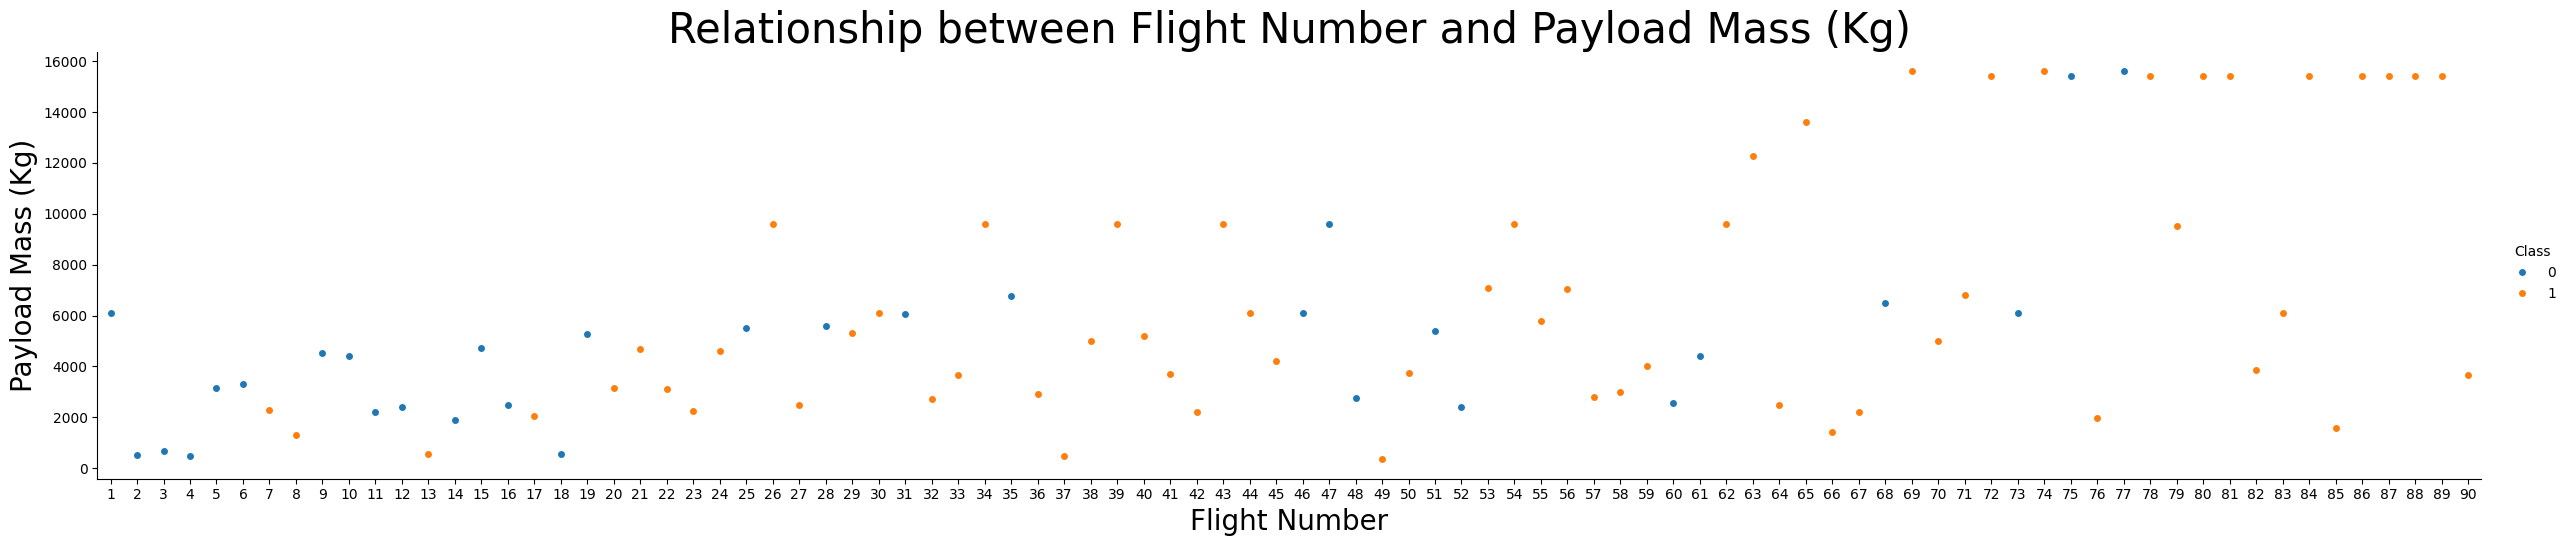

In [162]:
sns.catplot(y=df['PayloadMass'], x=df['FlightNumber'], hue=df['Class'], aspect=5)
plt.title('Relationship between Flight Number and Payload Mass (Kg)',fontsize=30)
plt.xlabel('Flight Number', fontsize=20)
plt.ylabel('Payload Mass (Kg)', fontsize=20)
plt.show()

It seems that as bigger the payload mass more chances of success and the last launches were successful.

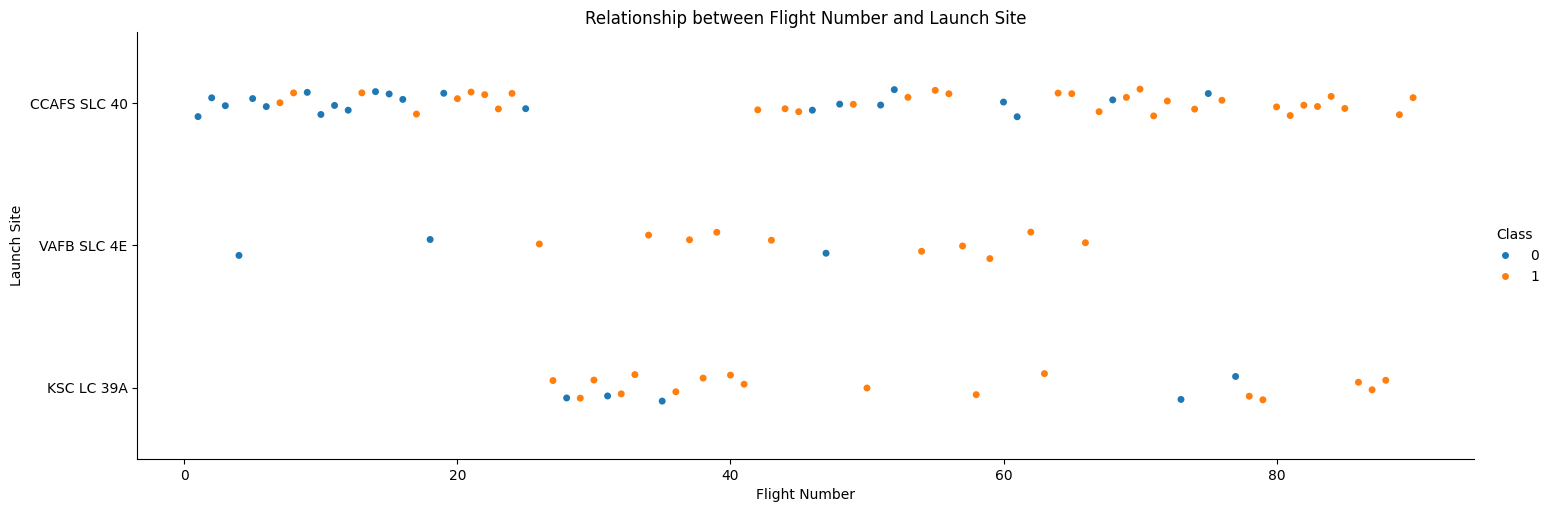

In [160]:
sns.catplot(x=df['FlightNumber'], y=df['LaunchSite'], hue=df['Class'], aspect=3)
plt.title('Relationship between Flight Number and Launch Site')
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.show()

It seems that SLC 4E has a higher rate of success and SLC 40 has more launches and the first 20 launches were almost unsuccesful.

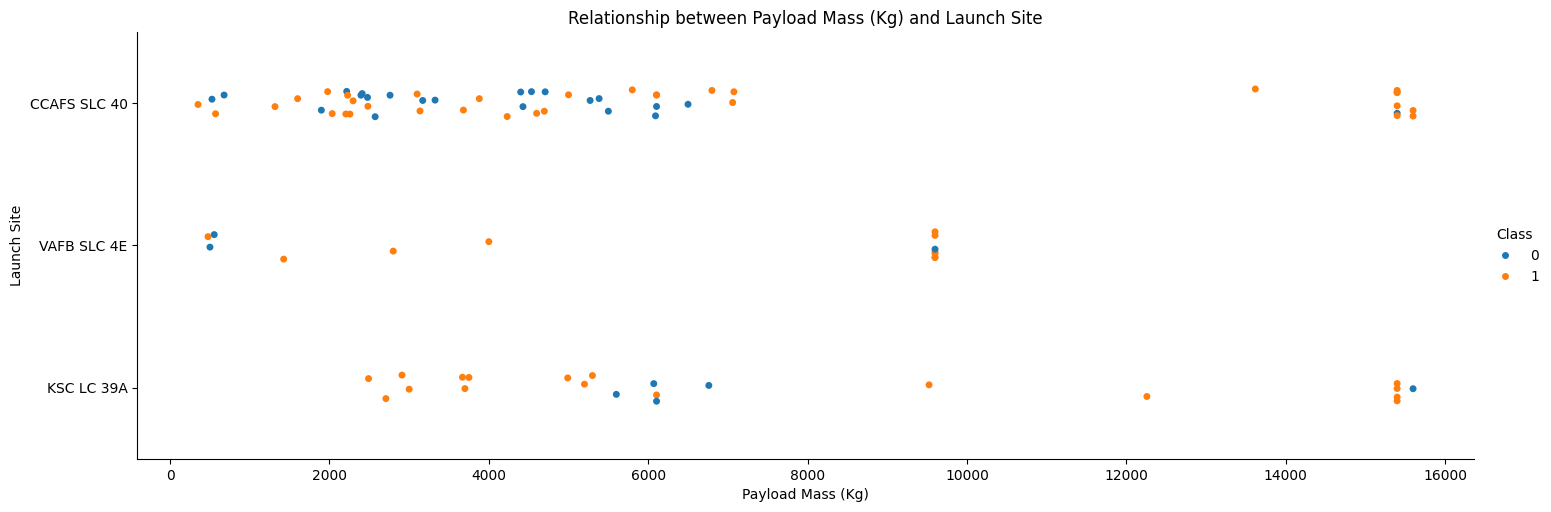

In [182]:
sns.catplot(x=df['PayloadMass'], y=df['LaunchSite'], hue=df['Class'], aspect=3)
plt.title('Relationship between Payload Mass (Kg) and Launch Site')
plt.xlabel('Payload Mass (Kg)')
plt.ylabel('Launch Site')
plt.show()

It seems that as bigger the payload mass as more succesful launches, LC 39A seems to work well with small payload mass.

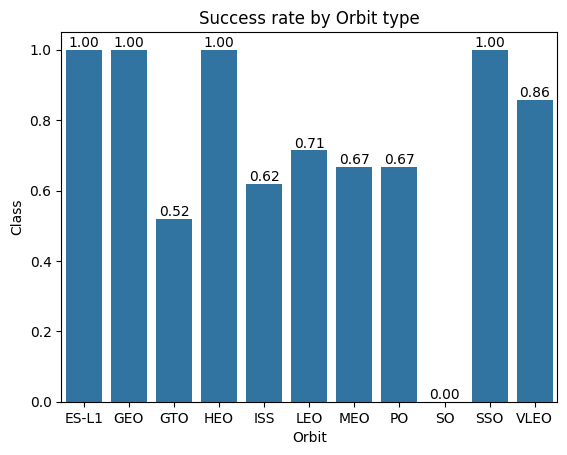

In [172]:
gp_orbit = df.groupby(by=['Orbit'], as_index=False).agg({'Class':'mean'})
ax = sns.barplot(x=gp_orbit['Orbit'], y=gp_orbit['Class'])
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.title('Success rate by Orbit type')
plt.show()

Launches to orbits such as ES-L1, GEO, HEO, SSO have all succesful returns of first stage.

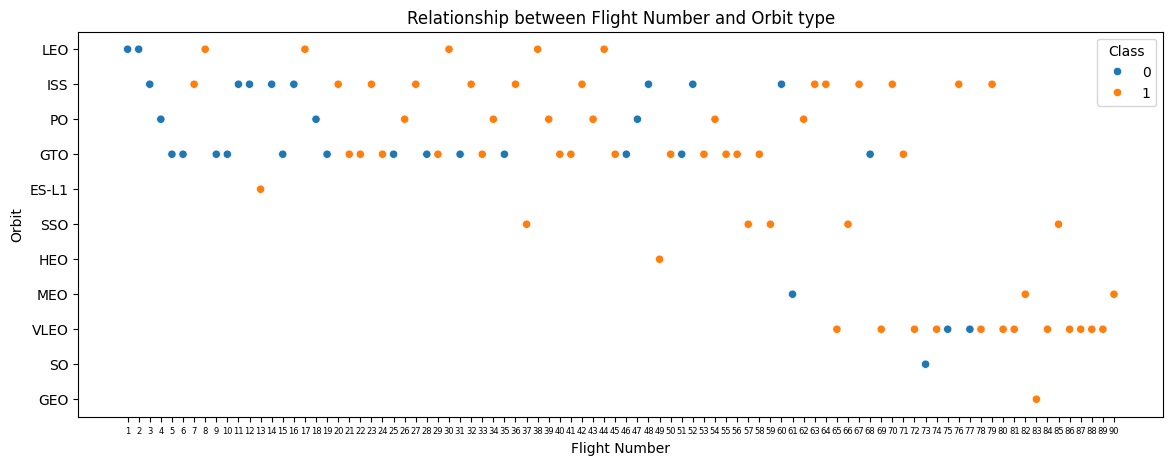

In [181]:
fig = plt.figure(figsize=(14,5))
sns.scatterplot(x=df['FlightNumber'], y=df['Orbit'], hue=df['Class'])
plt.title('Relationship between Flight Number and Orbit type')
plt.xlabel('Flight Number')
plt.xticks(df['FlightNumber'], fontsize=6)
plt.show()

Most of the orbits seems to get better results as the Flight Number increases except for ISS, GTO, VLEO and SO.

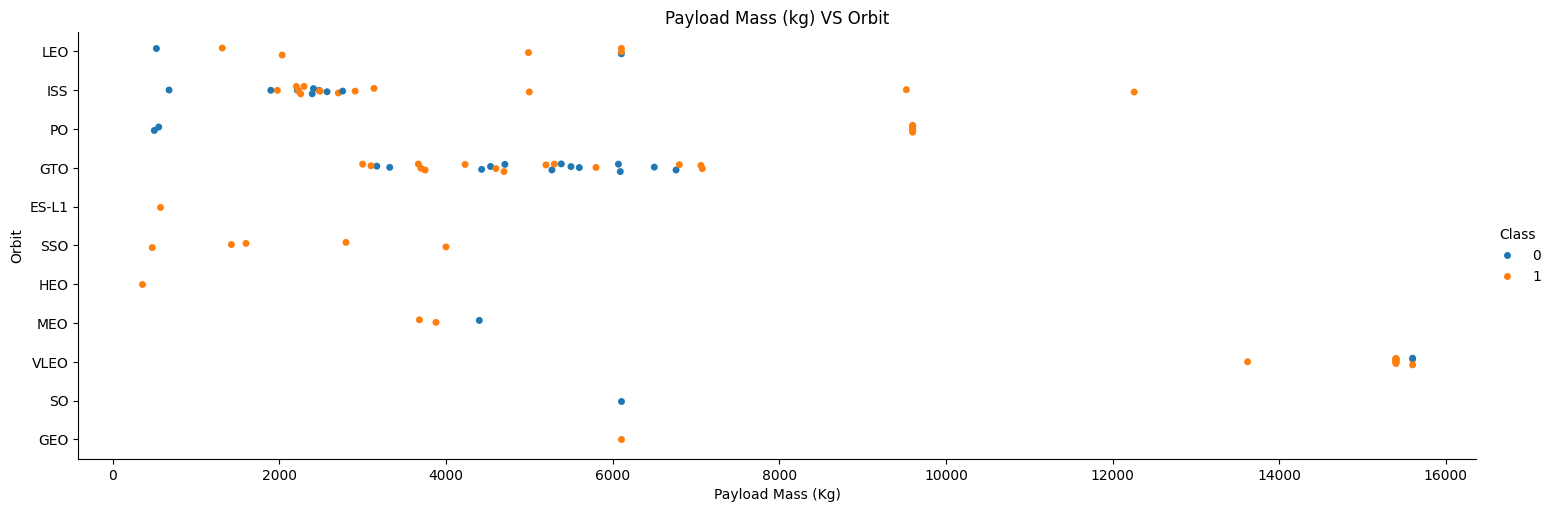

In [183]:
sns.catplot(x=df['PayloadMass'], y=df['Orbit'], hue=df['Class'], aspect=3)
plt.title('Payload Mass (kg) VS Orbit')
plt.xlabel('Payload Mass (Kg)')
plt.show()

With heavy payloads the succesful landing are more for ISS, PO and VLEO. GTO seems that has not relation with payload mass.

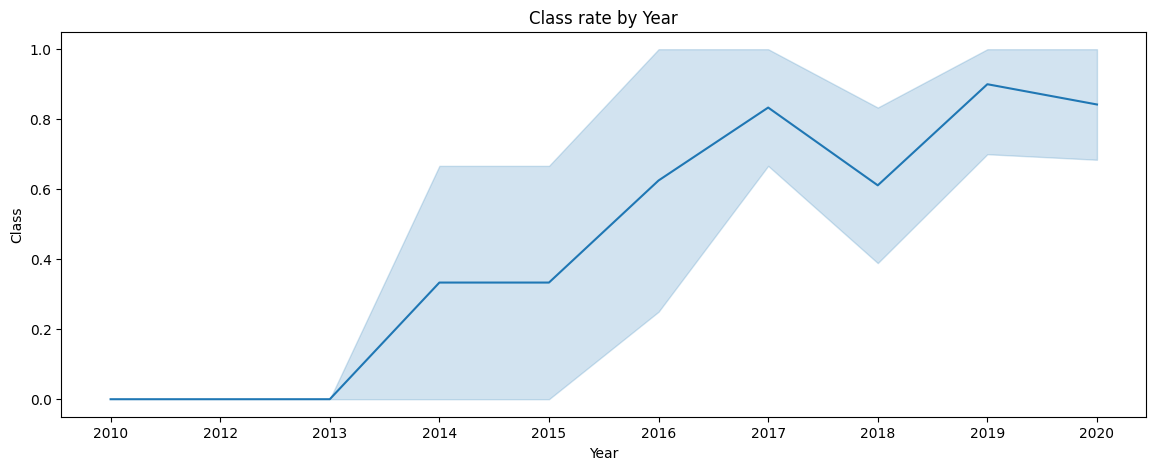

In [191]:
df['year'] = df['Date'].map(lambda x: x.split('-')[0])
fig = plt.figure(figsize=(14,5))
sns.lineplot(x=df['year'], y=df['Class'], estimator='mean')
plt.title('Class rate by Year')
plt.xlabel('Year')
plt.show()

We can see that the success rate start to increase in 2013 and keep increasin till 2017 for a decrease in 2018.

Let´s now select the features that will be used in success prediction.

In [193]:
features = df[['FlightNumber','PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


Now let´s apply one-hot-encoding for the categorical variables.

In [228]:
dummies_orbit = pd.get_dummies(features['Orbit'],prefix='Orbit')
dummies_launchsite = pd.get_dummies(features['LaunchSite'], prefix='LS')
dummies_landingpad = pd.get_dummies(features['LandingPad'], prefix='LP')
dummies_serial = pd.get_dummies(features['Serial'], prefix= 'Serial')

features_one_hot = pd.concat([features,dummies_orbit,dummies_launchsite,dummies_landingpad,dummies_serial], axis=1)
features_one_hot.drop(columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'], inplace= True)
features_one_hot = features_one_hot.astype(float)

features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LS_CCAFS SLC 40,LS_KSC LC 39A,LS_VAFB SLC 4E,LP_5e9e3032383ecb267a34e7c7,LP_5e9e3032383ecb554034e7c9,LP_5e9e3032383ecb6bb234e7ca,LP_5e9e3032383ecb761634e7cb,LP_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [230]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

### Launch sites locations analysis using Folium

The tasks for this section are:
- Mark all launches sites on a map
- Mark the success/failed launches for each site on the map


In [328]:
# get the data
geo = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')

#get relevant columns 
geo = geo[['Launch Site', 'Lat', 'Long','class']]

launch_sites = geo.groupby(by=['Launch Site'], as_index=False).first()
launch_sites.drop(columns=['class'],inplace=True)
launch_sites

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


In [330]:
# start location is NASA Johnson Space Center
import folium.map


nasa_coordinate = [29.559684888503615, -95.0830971930759]
# create the folium map
site_map = folium.Map(location=nasa_coordinate,zoom_start=4)

# create a blue ,fill=Truecircle in nasa_coordinate
circle_nasa = folium.Circle(nasa_coordinate, radius=1000, color='#0051d3', fill=True).add_child(folium.Popup('NASA Johnson Space Center'))
marker_nasa = folium.map.Marker(
    nasa_coordinate,
    icon= DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#0051d3;"><b>%s</b></div>' % 'NASA JSC',
    )
)

site_map.add_child(circle_nasa)
site_map.add_child(marker_nasa)

# create circles and markers for each launch site

coordinate_0 = [28.562302,-80.577356]
coordinate_1 = [28.563197,-80.576820]
coordinate_2 = [28.573255,-80.646895]
coordinate_3 = [34.632834,-120.610745]

circle_0 = folium.Circle(coordinate_0,tooltip="CCAFS LC-40", color='blue',fill=True).add_to(site_map)
circle_1 = folium.Circle(coordinate_1,tooltip="CCAFS SLC-40", color='blue',fill=True).add_to(site_map)
circle_2 = folium.Circle(coordinate_2,tooltip="KSC LC-39A", color='blue',fill=True).add_to(site_map)
circle_3 = folium.Circle(coordinate_3,tooltip="VAFB SLC-4E",color='blue',fill=True).add_to(site_map)


# Create markers for each launch site with color depending on the class
geo['color'] = geo['class'].map(lambda x: 'green' if x == 1 else 'red')
marker_cluster = MarkerCluster()
site_map.add_child(marker_cluster)

for index, row in geo.iterrows():
    marker = folium.Marker([row['Lat'],row['Long']],icon=folium.Icon(color=row['color']))
    marker_cluster.add_child(marker)

# Add distance between a launch site to its proximities
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)
site_map.add_child(mouse_position)

## Model Selection

In [238]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [239]:
### Replace for X = features-one-hot
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
X.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


Set the Y and X into an array and standarize X (Standarization is specially good for models such as Logistic regression, SVM, KNN)

In [243]:
Y = df['Class'].to_numpy()
X = preprocessing.StandardScaler().fit_transform(X)


numpy.ndarray

In [251]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

### Logistic Regression

We'll use GridSearchCV to find the best parameters

In [262]:
# Create the parameters
parameters = {'C':[0.01,0.1,1],
              'penalty':['l2'],
              'solver':['lbfgs']}

# Create the model and the gridsearchcv
lr = LogisticRegression()
lr_cv = GridSearchCV(lr,param_grid=parameters, cv = 10)

# Fit the model
lr_cv.fit(X_train,y_train)


print(f'Best parameters: {lr_cv.best_params_}')
print(f'Acurracy: {lr_cv.best_score_}')

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Acurracy: 0.8464285714285713


Let´s look at the score using the test data with the best parameters

In [263]:
lr_cv.score(X_test,y_test)

0.8333333333333334

And let's look at the confusion matrix

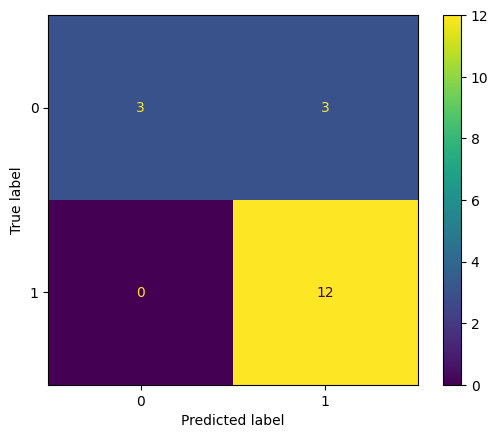

In [264]:
yhat = lr_cv.predict(X_test)
cm = confusion_matrix(y_test,yhat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

As we can see, the problem is with false positives

### SVM

In [278]:
# Create the parameters
parameters = {'kernel':('linear','rbf','poly','rbf','sigmoid'),
              'C':np.logspace(-3,3,5),
              'gamma':np.logspace(-3,3,5)}

# Create the model
svm = SVC()
svm_cv = GridSearchCV(svm, param_grid=parameters,cv=10)

# Fit the model
svm_cv.fit(X_train,y_train)

print(f'Best parameters: {svm_cv.best_estimator_}')
print(f'Accuracy: {svm_cv.best_score_}')

Best parameters: SVC(C=np.float64(1.0), gamma=np.float64(0.03162277660168379), kernel='sigmoid')
Accuracy: 0.8482142857142856


In [281]:
svm_cv.score(X_test,y_test)

0.8333333333333334

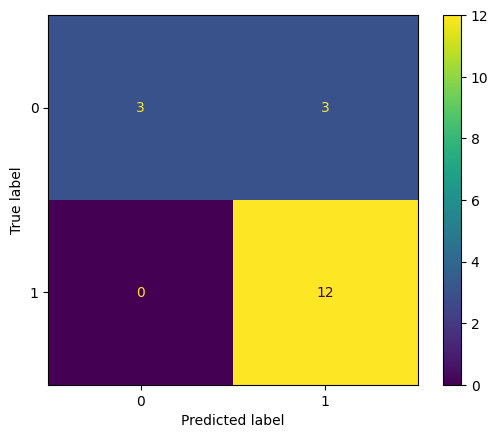

In [271]:
yhat =  svm_cv.predict(X_test)

cm_svm = confusion_matrix(y_test, yhat)
ConfusionMatrixDisplay(confusion_matrix=cm_svm).plot()
plt.show()

We can see that the SVM model has the same results as the logistic regression

### Decision Tree

In [282]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2*n for n in range(1,10)],
              'max_features':['sqrt', 'log2'],
              'min_samples_leaf': [1,2,4],
              'min_samples_split': [2,5,10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, param_grid= parameters, cv=10)

tree_cv.fit(X_train, y_train)

print(f'Best parameters: {tree_cv.best_estimator_}')
print(f'Accuracy: {tree_cv.best_score_}')

Best parameters: DecisionTreeClassifier(criterion='entropy', max_depth=4, max_features='sqrt',
                       min_samples_leaf=2, min_samples_split=5,
                       splitter='random')
Accuracy: 0.875


In [277]:
tree_cv.score(X_test,y_test)

0.8888888888888888

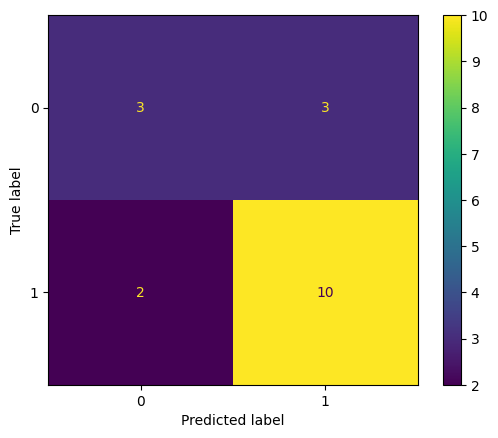

In [283]:
yhat = tree_cv.predict(X_test)

cm_tree = confusion_matrix(y_test,yhat)
ConfusionMatrixDisplay(confusion_matrix= cm_tree).plot()
plt.show()

We see that the score improves but in the confusion matrix we see that predicted wrong two of the 12 True label.

### KNN

In [284]:
parameters = {'n_neighbors': [n for n in range(1,10)],
              'algorithm': ['auto','ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid= parameters, cv=10)

knn_cv.fit(X_train,y_train)

print(f'Best parameters: {knn_cv.best_estimator_}')
print(f'Accuracy: {knn_cv.best_score_}')

Best parameters: KNeighborsClassifier(n_neighbors=4)
Accuracy: 0.8464285714285713


In [285]:
knn_cv.score(X_test,y_test)

0.7777777777777778

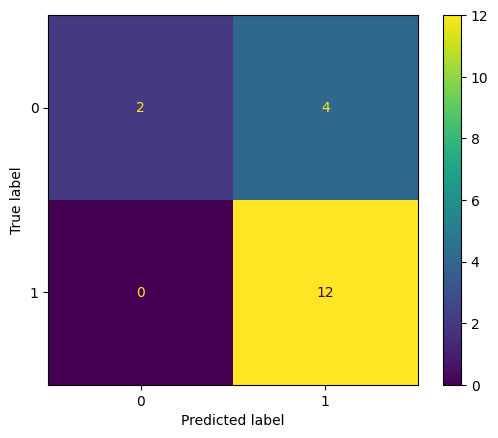

In [286]:
yhat = knn_cv.predict(X_test)

cm_knn = confusion_matrix(y_test,yhat)
ConfusionMatrixDisplay(confusion_matrix=cm_knn).plot()
plt.show()

At the moment, KNN model has the lower score.

It seems that the Decision Tree model has the best accuracy when did the cross validation. In addition, the logistic regression and the SVM model gives pretty the same results.